# TMO: BiphasicDiscovery - Human Brain

In [1]:
# ============================================================
# CONFIGURATION – change only this cell for each dataset
# ============================================================
DATASET = "human_brain"
ANNDATA_PATH = f"../data/10x_{DATASET}/human_brain_gene_level_tmo_ready.h5ad"
RESULTS_DIR  = f"../results/tmo_results_human_brain_cmmd"
TARGET_FILE  = f"../data/10x_{DATASET}/ASCL1_top500_genes.txt"
TF_NAME      = "ASCL1"

# ------------------------------------------------------------
# Imports and warnings
# ------------------------------------------------------------
import warnings, numpy as np, pandas as pd, scanpy as sc, anndata as ad
from scipy.stats import mannwhitneyu, spearmanr, pearsonr
from scipy.interpolate import interp1d
from scipy.signal import correlate
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.decomposition import TruncatedSVD
from tmo.ccf import local_ccf_surface, smooth_delta_tau_surface

warnings.filterwarnings("ignore", module="anndata")
warnings.filterwarnings("ignore", module="sklearn.gaussian_process")

In [2]:
# Load Δτ surface and correlation matrix saved by 4_evaluate_asymmetric.py and 5_plot_correlation_heatmap.py
delta_tau_smooth = np.loadtxt(f"{RESULTS_DIR}/delta_tau_smooth.csv", delimiter=",")
max_corr_per_bin = np.loadtxt(f"{RESULTS_DIR}/atac_rna_correlation_heatmap.csv", delimiter=",")

print(f"Δτ surface: {delta_tau_smooth.shape}  (components x windows)")
print(f"Correlation matrix: {max_corr_per_bin.shape}  (bins x components)")

Δτ surface: (50, 11)  (components x windows)
Correlation matrix: (10, 50)  (bins x components)


In [3]:
# ============================================================
# Cell 3 – Gene‑level cross‑correlation (CCF) and ChIP‑seq validation
# ============================================================
# This cell computes, for every gene, a scalar regulatory lag
# by cross‑correlating its ATAC and RNA profiles along pseudotime.
# The resulting lags are then used in a deterministic ChIP‑seq test
# (two‑sided Mann‑Whitney U) to compare target vs. background genes.
# This provides an independent, model‑free validation that the
# regulatory lag signal exists in the raw data.

def compute_gene_lag_ccf(adata):
    """
    Compute a scalar regulatory lag for each gene by cross‑correlating
    its ATAC accessibility and RNA expression along pseudotime.

    The procedure mirrors the component‑level CCF used to train TMO,
    but applied directly to gene‑level matrices without dimensionality
    reduction.

    Steps:
    1. Sort cells by pseudotime (required for stable CCF).
    2. Subset to genes that have ATAC data.
    3. Interpolate the ATAC and RNA profiles onto a dense regular
       pseudotime grid to handle non‑uniform spacing.
    4. Standardise each gene’s ATAC and RNA profiles.
    5. For each gene, compute the full cross‑correlation and find
       the peak lag within ±0.3 pseudotime units.

    Parameters
    ----------
    adata : AnnData
        Must contain .X (log‑normalised RNA), .obsm['ATAC_gene'] (gene‑
        level ATAC), and .obs['pseudotime'] (sorted pseudotime).

    Returns
    -------
    pd.Series
        A series indexed by gene names, containing the scalar peak lag
        (in pseudotime units) for each gene.  NaN indicates that no
        reliable peak could be identified (e.g., constant profiles).
    """
    # Ensure cells are sorted by pseudotime (required by CCF)
    adata = adata[adata.obs['pseudotime'].argsort()].copy()

    # Restrict to genes that have ATAC data (first n_atac columns)
    atac_gene = adata.obsm['ATAC_gene'].toarray()
    n_atac = atac_gene.shape[1]
    adata = adata[:, :n_atac].copy()

    # RNA matrix (already log‑normalised)
    rna = adata.X.toarray() if hasattr(adata.X, 'toarray') else adata.X
    pt = adata.obs['pseudotime'].values

    # Separate the sorted arrays for interpolation
    sort_idx = np.argsort(pt)
    pt_sorted = pt[sort_idx]
    atac_sorted = atac_gene[sort_idx, :]
    rna_sorted = rna[sort_idx, :]

    # Interpolate onto a dense regular grid (200 points)
    # This ensures equal spacing, which is required for stable
    # cross‑correlation with scipy.signal.correlate.
    n_interp = 200
    pt_reg = np.linspace(pt_sorted.min(), pt_sorted.max(), n_interp)
    f_atac = interp1d(pt_sorted, atac_sorted, axis=0,
                      kind='linear', fill_value='extrapolate')
    f_rna  = interp1d(pt_sorted, rna_sorted, axis=0,
                      kind='linear', fill_value='extrapolate')
    atac_reg = f_atac(pt_reg)
    rna_reg  = f_rna(pt_reg)

    # Standardise each gene (zero mean, unit variance)
    # Adding 1e-8 avoids division by zero for constant genes.
    atac_reg = (atac_reg - atac_reg.mean(axis=0)) / (atac_reg.std(axis=0) + 1e-8)
    rna_reg  = (rna_reg  - rna_reg.mean(axis=0))  / (rna_reg.std(axis=0) + 1e-8)

    # Cross‑correlation parameters
    max_lag = 0.3           # maximum lag in pseudotime units
    dt = pt_reg[1] - pt_reg[0]          # time step on the regular grid
    max_lag_samples = int(max_lag / dt)  # max lag in grid steps

    n_genes = atac_reg.shape[1]
    lags = np.full(n_genes, np.nan)      # pre‑allocate with NaN

    # Compute peak lag for each gene
    for g in range(n_genes):
        # Full cross‑correlation (RNA vs ATAC)
        corr = correlate(rna_reg[:, g], atac_reg[:, g], mode='full')
        mid = len(corr) // 2               # index of zero lag
        start = max(0, mid - max_lag_samples)
        end = min(len(corr), mid + max_lag_samples + 1)
        if start >= end:
            continue                       # not enough data points
        # Find the lag with the highest correlation within ±max_lag
        peak_idx = start + np.argmax(corr[start:end])
        lag_samples = peak_idx - mid
        lags[g] = lag_samples * dt         # convert to pseudotime units

    # Return as a Series indexed by gene names
    return pd.Series(lags, index=adata.var_names)


# ----------------------------------------------------------------
# Load data and compute gene‑level lags
# ----------------------------------------------------------------
adata = ad.read_h5ad(ANNDATA_PATH)
if 'log1p' not in adata.uns:
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

gene_lag_ccf = compute_gene_lag_ccf(adata)
print(f"Gene‑level CCF lags computed for {gene_lag_ccf.notna().sum()} genes")

# ----------------------------------------------------------------
# Deterministic ChIP‑seq validation using gene‑level CCF lags
# ----------------------------------------------------------------
# Read the list of top‑500 target genes for this TF
with open(TARGET_FILE) as f:
    target_genes = [line.strip() for line in f if line.strip()]

# Keep only target genes present in the dataset
target_genes = [g for g in target_genes if g in gene_lag_ccf.index]
print(f"Target genes found: {len(target_genes)}")

# Background = all non‑target genes (no random subsampling)
bg_genes = [g for g in gene_lag_ccf.index if g not in target_genes]
print(f"Background genes: {len(bg_genes)}")

# Extract the lag values for the two groups
t_lags = gene_lag_ccf[target_genes].dropna().values
b_lags = gene_lag_ccf[bg_genes].dropna().values

# Two‑sided Mann‑Whitney U test
stat, p_gene = mannwhitneyu(t_lags, b_lags, alternative='two-sided')

print(f"\n=== Gene‑level CCF ChIP‑seq validation ({TF_NAME}) ===")
print(f"Target Δτ mean:     {np.mean(t_lags):.6f}")
print(f"Background Δτ mean: {np.mean(b_lags):.6f}")
print(f"Mann‑Whitney U = {stat:.0f}, p = {p_gene:.4e}")

Gene‑level CCF lags computed for 30496 genes
Target genes found: 421
Background genes: 30075

=== Gene‑level CCF ChIP‑seq validation (ASCL1) ===
Target Δτ mean:     -0.084353
Background Δτ mean: -0.124507
Mann‑Whitney U = 7485956, p = 8.3426e-11


In [4]:
# ------------------------------------------------------------
# Subset adata to ATAC genes so that PCA loadings match gene_lag_ccf
# ------------------------------------------------------------
atac_gene = adata.obsm['ATAC_gene'].toarray()
n_atac = atac_gene.shape[1]
adata_sub = adata[:, :n_atac].copy()
rna_sub = adata_sub.X.toarray() if hasattr(adata_sub.X, 'toarray') else adata_sub.X

# Recompute PCA on the subsetted data
pca_sub = PCA(n_components=50, random_state=42).fit(rna_sub)
loadings = pca_sub.components_          # (50, n_atac)

# Get top 100 gene indices per component (now safe)
top_genes_per_comp = []
for comp in range(50):
    abs_load = np.abs(loadings[comp])
    top_idx = np.argsort(-abs_load)[:100]
    top_genes_per_comp.append(top_idx)

# Within‑component variance
within_std = []
for comp in range(50):
    vals = gene_lag_ccf.iloc[top_genes_per_comp[comp]].dropna()
    if len(vals) > 10:
        within_std.append(vals.std())
within_std = np.array(within_std)
median_within_std = np.median(within_std)

# TMO profile variance
tmo_profile_std = np.std(delta_tau_smooth, axis=1)
median_tmo_std = np.median(tmo_profile_std)

print(f"Median within‑component gene‑level std: {median_within_std:.4f}")
print(f"Median TMO profile std (across pseudotime): {median_tmo_std:.4f}")
print(f"Ratio (gene‑level / TMO): {median_within_std / median_tmo_std:.2f}")

Median within‑component gene‑level std: 0.1431
Median TMO profile std (across pseudotime): 0.0342
Ratio (gene‑level / TMO): 4.19


Template for 11 windows: [ 1.   1.  -0.5 -1.  -1.  -1.  -1.  -1.  -0.5  1.   1. ]

Permutation test (1000 shuffles):
  Component 38: r=0.778, p=0.0020
  Component 29: r=0.680, p=0.0050
  Component 16: r=0.610, p=0.0060
  Component 24: r=0.449, p=0.0710
  Component 41: r=0.432, p=0.0900
  Component 48: r=0.358, p=0.1320
  Component 47: r=0.346, p=0.1290
  Component 15: r=0.345, p=0.1450
  Component 11: r=0.312, p=0.1570
  Component 23: r=0.283, p=0.1870

Correlation profiles (10 bins) for top U‑shaped components:
  Component 38: [0.4834 0.1984 0.1036 0.1052 0.1122 0.2022 0.1789 0.1471 0.2951 0.3558]
  Component 29: [0.4998 0.231  0.1645 0.1909 0.1885 0.2578 0.1942 0.3099 0.2907 0.4843]
  Component 16: [0.4117 0.2418 0.1491 0.16   0.2012 0.2247 0.2279 0.3528 0.524  0.7692]
  Component 24: [0.4153 0.2951 0.1684 0.1606 0.1619 0.2006 0.2606 0.2161 0.3169 0.4551]
  Component 41: [0.4433 0.1113 0.1361 0.0794 0.1078 0.1417 0.1882 0.1302 0.3535 0.4245]
  Component 48: [0.378  0.1851 0.0968 0.12

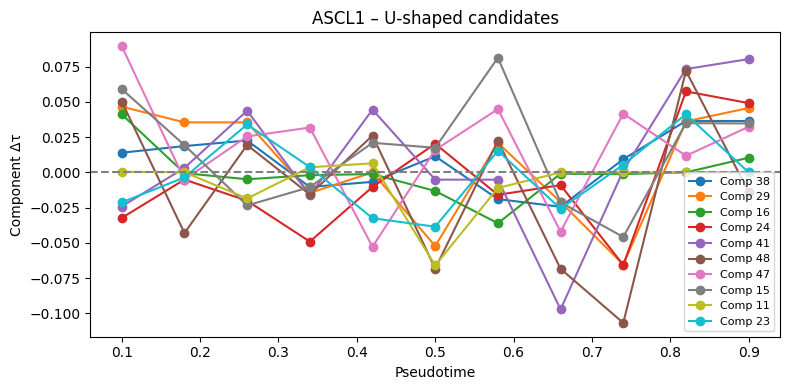

In [5]:
# ============================================================
# Biphasic U‑shape discovery (template auto‑adjusted to data)
# ============================================================

# Detect the number of pseudotime windows from the CSV
n_windows = delta_tau_smooth.shape[1]

# Top n_comps to analyse
n_comps = 10

# Build a U‑shape template with the same number of points
# The template goes: positive early → negative middle → positive late
half = n_windows // 2
template = np.ones(n_windows)
template[half-2:half+3] = -1          # central dip
# Smooth the transitions a bit
if n_windows >= 9:
    template[half-3] = -0.5
    template[half+3] = -0.5
print(f"Template for {n_windows} windows: {np.round(template, 2)}")

# Compute U‑shape scores for all 50 components
u_scores = np.array([
    np.corrcoef(delta_tau_smooth[comp], template)[0, 1] if np.std(delta_tau_smooth[comp]) > 0
    else np.nan
    for comp in range(50)
])
top_comps = np.argsort(-u_scores)[:10]   # top 10 candidates

# Permutation test for top 5
print("\nPermutation test (1000 shuffles):")
perm_pvals = {}
for comp in top_comps[:n_comps]:
    profile = delta_tau_smooth[comp]
    obs_r = u_scores[comp]
    null_rs = [np.corrcoef(np.random.permutation(profile), template)[0, 1] for _ in range(1000)]
    p_val = np.mean(null_rs >= obs_r)
    perm_pvals[comp] = p_val
    print(f"  Component {comp}: r={obs_r:.3f}, p={p_val:.4f}")

# Correlation profiles for the top n_comps
print("\nCorrelation profiles (10 bins) for top U‑shaped components:")
for comp in top_comps[:n_comps]:
    print(f"  Component {comp}: {np.round(max_corr_per_bin[:, comp], 4)}")

# Plot the biphasic profiles
fig, ax = plt.subplots(figsize=(8, 4))
for comp in top_comps[:n_comps]:
    ax.plot(np.linspace(0.1, 0.9, n_windows), delta_tau_smooth[comp], 'o-', label=f'Comp {comp}')
ax.axhline(0, color='gray', ls='--')
ax.set_xlabel('Pseudotime')
ax.set_ylabel('Component Δτ')
ax.set_title(f'{TF_NAME} – U‑shaped candidates')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/biphasic_candidates_{DATASET}.pdf", dpi=150)
plt.show()

In [6]:
import numpy as np
np.set_printoptions(linewidth=200, precision=4, suppress=True)

delta = np.loadtxt("../results/tmo_results_human_brain_cmmd/delta_tau_smooth.csv", delimiter=",")
corr  = np.loadtxt("../results/tmo_results_human_brain_cmmd/atac_rna_correlation_heatmap.csv", delimiter=",")

print("=== Δτ surface (50 components x 11 windows) ===")
print(delta)
print()
print("=== Correlation matrix (10 bins x 50 components) ===")
print(corr)

=== Δτ surface (50 components x 11 windows) ===
[[-0.0345  0.0001  0.0053 -0.0441  0.0413 -0.0152 -0.0153 -0.0189 -0.0372  0.0073  0.045 ]
 [ 0.      0.     -0.      0.      0.0853  0.053  -0.0024 -0.0031  0.0061  0.0057 -0.0012]
 [ 0.      0.      0.      0.      0.      0.      0.      0.      0.      0.      0.    ]
 [-0.0469  0.0406 -0.     -0.     -0.     -0.     -0.     -0.     -0.     -0.     -0.    ]
 [-0.0297 -0.0085  0.0072 -0.0447  0.001   0.1173  0.0838 -0.0344 -0.0247  0.0162  0.1109]
 [-0.0103 -0.0329 -0.0138 -0.0045  0.003   0.0031  0.1094  0.0092  0.0093  0.0282  0.0271]
 [ 0.0385  0.0024 -0.     -0.     -0.     -0.     -0.     -0.     -0.     -0.0003 -0.0602]
 [ 0.0326 -0.0459  0.0029  0.019  -0.0285 -0.0077  0.0849  0.057   0.0436  0.0466  0.0474]
 [ 0.      0.      0.      0.      0.      0.      0.      0.      0.      0.      0.    ]
 [-0.029  -0.0402  0.0011 -0.0516 -0.     -0.     -0.     -0.     -0.     -0.     -0.    ]
 [ 0.0608 -0.0461  0.0026  0.      0.     